In [12]:
%cd ..

/Users/rubenmarcus/Desktop/Code/Personal Projects/Deep Hedging


In [19]:
import numpy as np
import pandas as pd

from src.models.gbm import simulate_gbm
from src.strategies.delta_hedge import run_delta_hedge

In [13]:
S0 = 100
K = 100
sigma = 0.2
T = 1.0
r = 0.04

n_paths = 100_000

frequencies = [1, 4, 12, 52, 252]

In [ ]:
results = []
pnl_by_frequency = {}

for n_steps in frequencies:
    result = simulate_gbm(
        S0=S0,
        sigma=sigma,
        T=T,
        n_steps=n_steps,
        n_paths=n_paths,
        r=r,
        seed=123 + n_steps,
    ).spot

    hedge = run_delta_hedge(
        stock_paths=paths,
        K=K,
        sigma=sigma,
        T=T,
        r=r,
        record_history=False
    )

    pnl = hedge["pnl"]

    mean_pnl = np.mean(pnl)
    std_pnl = np.std(pnl, ddof=1)
    standard_error = std_pnl / np.sqrt(n_paths)

    results.append({
        "n_steps": n_steps,
        "mean_pnl": mean_pnl,
        "std_pnl": std_pnl,
        "se_mean": standard_error,
    })

    pnl_by_frequency[n_steps] = pnl

results = pd.DataFrame(results)

print(results)


   n_steps  mean_pnl   std_pnl   se_mean
0        1  0.001482  0.439059  0.001388
1        4  0.001482  0.439059  0.001388
2       12  0.001482  0.439059  0.001388
3       52  0.001482  0.439059  0.001388
4      252  0.001482  0.439059  0.001388


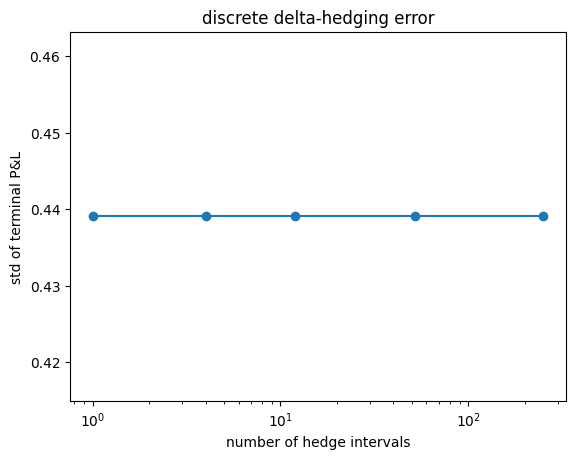

In [15]:
import matplotlib.pyplot as plt


plt.figure()

plt.plot(
    results["n_steps"],
    results["std_pnl"],
    marker="o",
)

plt.xscale("log")

plt.xlabel("number of hedge intervals")
plt.ylabel("std of terminal P&L")
plt.title("discrete delta-hedging error")

plt.show()

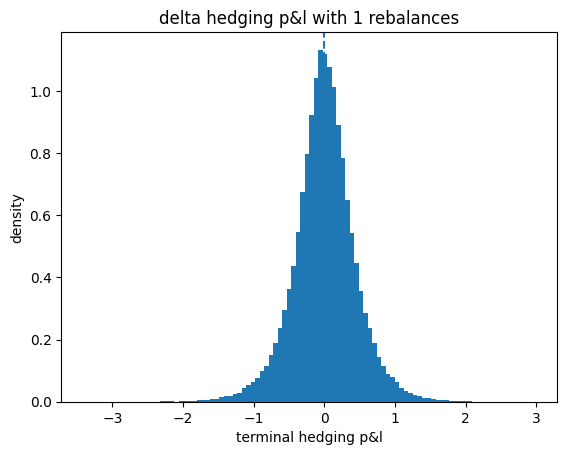

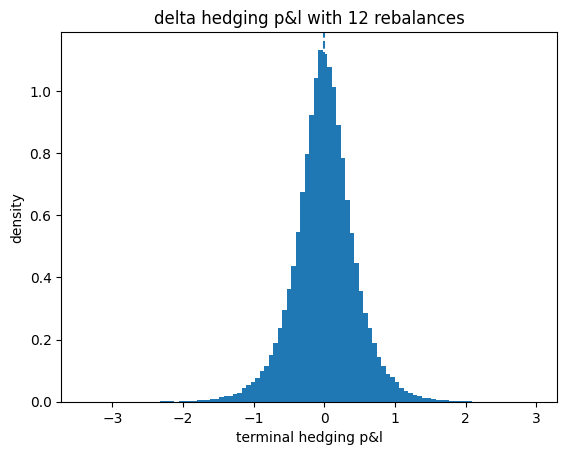

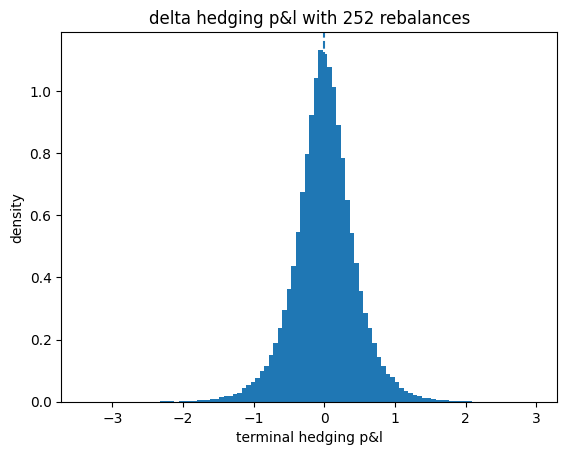

In [ ]:
for n_steps in [1, 12, 252]:
    pnl = pnl_by_frequency[n_steps]

    plt.figure()

    plt.hist(pnl, bins=100, density=True)

    plt.axvline(0.0, linestyle="--")

    plt.xlabel("terminal hedging p&l")
    plt.ylabel("density")

    plt.title(f"delta hedging p&l with {n_steps} rebalances"    )

    plt.show()

# transaction costs

In [ ]:
r = 0.04

cost_rates = [0.0, 0.005, 0.01] 

cost_results = []
pnl_by_cost = {}

for rate in cost_rates:
    for n_steps in frequencies:
        paths = simulate_gbm(
            S0=S0,
            sigma=sigma,
            T=T,
            n_steps=n_steps,
            n_paths=n_paths,
            r=r,
            seed=123 + n_steps,
        ).spot

        hedge = run_delta_hedge(
            stock_paths=paths,
            K=K,
            sigma=sigma,
            T=T,
            r=r,
            transaction_cost_rate=rate,
            record_history=False,
        )

        pnl = hedge["pnl"]
        tc = hedge["transaction_costs"]

        mean_pnl = np.mean(pnl)
        std_pnl = np.std(pnl, ddof=1)
        standard_error = std_pnl / np.sqrt(n_paths)

        cost_results.append({
            "cost_rate": rate,
            "n_steps": n_steps,
            "mean_pnl": mean_pnl,
            "std_pnl": std_pnl,
            "se_mean": standard_error,
            "mean_transaction_cost": np.mean(tc),
        })

        pnl_by_cost[(rate, n_steps)] = pnl

cost_results = pd.DataFrame(cost_results)

print(cost_results)


    cost_rate  n_steps  mean_pnl   std_pnl   se_mean  mean_transaction_cost
0       0.000        1  0.013643  5.968920  0.018875               0.000000
1       0.000        4  0.001493  3.239474  0.010244               0.000000
2       0.000       12  0.000207  1.935388  0.006120               0.000000
3       0.000       52  0.004610  0.959142  0.003033               0.000000
4       0.000      252  0.001482  0.439059  0.001388               0.000000
5       0.005        1 -0.307921  5.968920  0.018875               0.308956
6       0.005        4 -0.573661  3.289312  0.010402               0.557576
7       0.005       12 -0.839864  1.994805  0.006308               0.817315
8       0.005       52 -1.450243  1.091299  0.003451               1.420010
9       0.005      252 -2.834535  1.064161  0.003365               2.773898
10      0.010        1 -0.629485  5.968920  0.018875               0.617911
11      0.010        4 -1.148816  3.340744  0.010564               1.115151
12      0.01

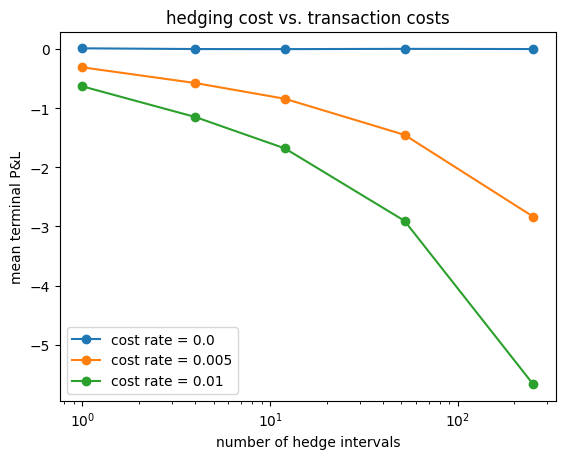

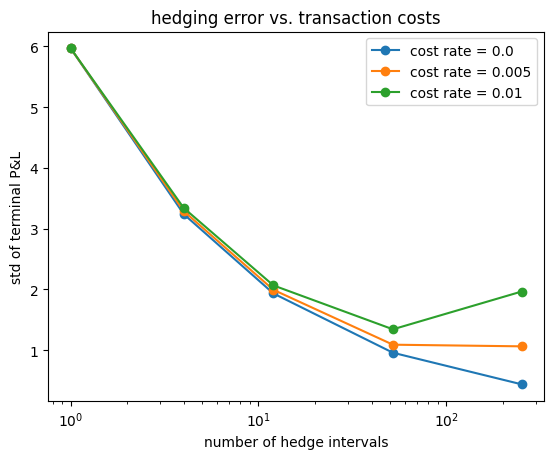

In [ ]:
plt.figure()

for rate in cost_rates:
    subset = cost_results[cost_results["cost_rate"] == rate]

    plt.plot(
        subset["n_steps"],
        subset["mean_pnl"],
        marker="o",
        label=f"cost rate = {rate}",
    )

plt.xscale("log")

plt.xlabel("number of hedge intervals")
plt.ylabel("mean terminal P&L")
plt.title("hedging cost vs. transaction costs")
plt.legend()

plt.show()


plt.figure()

for rate in cost_rates:
    subset = cost_results[cost_results["cost_rate"] == rate]

    plt.plot(
        subset["n_steps"],
        subset["std_pnl"],
        marker="o",
        label=f"cost rate = {rate}",
    )

plt.xscale("log")

plt.xlabel("number of hedge intervals")
plt.ylabel("std of terminal P&L")
plt.title("hedging error vs. transaction costs")
plt.legend()

plt.show()